# *"Is Having a Boyfriend Embarrassing Now?"*
## *Linguistic Analysis of a Vogue Article on Feminism and Relationships*

---

**Source:** *Vogue* — Chanté Joseph (October 2025)  
**Author:** Darya Malashonak  
**Course:** Academic Writing  

---

This notebook examines the language used in Chanté Joseph's *British Vogue* article on feminism, relationships and women's independence. Using basic NLP techniques in Python, I identify recurring linguistic patterns in the text and consider what they may suggest about the broader cultural debate the article provoked.

## 1. Introduction

In October 2025, journalist **Chanté Joseph** published an opinion piece in *British Vogue* titled *"Is Having a Boyfriend Embarrassing Now?"*. The article attracted considerable attention online and prompted widespread discussion about relationships, feminism and women's independence.

The aim of this project is not to evaluate the author's position. Instead, I examine several linguistic features of the text using Python and NLTK: word frequencies, parts of speech, lexical richness and named entities. These methods help to surface patterns that may not be immediately visible through ordinary reading.


## 2. Importing Libraries

The following cell imports all libraries used throughout the notebook: `requests` and `BeautifulSoup` for web scraping, `nltk` for tokenisation, POS tagging and NER, `pandas` for tabular display and `matplotlib` for visualisations. The necessary NLTK data packages are also downloaded here.

In [1]:
import requests
import re
from bs4 import BeautifulSoup

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag, FreqDist

import pandas as pd
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /r

True

## 3. Collecting Data

The article is collected by sending an HTTP request to the *British Vogue* webpage and parsing the HTML response with BeautifulSoup. Because the page contains navigation, promotional content and other elements beyond the article itself, the extraction is anchored to the article's known opening and closing phrases, retaining only the body text. The extracted text is stored as `corpus` and the first and last 1,000 characters are displayed below to confirm the extraction was successful.

In [2]:
url = "https://www.vogue.com/article/is-having-a-boyfriend-embarrassing-now"

response = requests.get(
    url,
    headers={
        "User-Agent": "Mozilla/5.0"
    }
)

soup = BeautifulSoup(response.text, "html.parser")

text = soup.get_text(" ")

text = re.sub(r"\s+", " ", text).strip()

start_phrase = (
    "If someone so much as says"
)

end_phrase = (
    "another nail in the coffin of a centuries-old heterosexual fairytale "
    "that never really benefited women to begin with."
)

start = text.find(start_phrase)
end = text.find(end_phrase)

if start == -1:
    raise ValueError("Article start not found")

if end == -1:
    raise ValueError("Article end not found")

corpus = text[start : end + len(end_phrase)]

print("Word count:", len(corpus.split()))
print()
print(corpus[:1000])
print("...")
print(corpus[-1000:])

Word count: 994

If someone so much as says “my boyf–” on social media, they’re muted. There’s nothing I hate more than following someone for fun, only for their content to become “my boyfriend”-ified suddenly. This is probably because, for so long, it felt like we were living in what one of my favorite Substackers calls Boyfriend Land : a world where women’s online identities centered around the lives of their partners, a situation rarely seen reversed. Women were rewarded for their ability to find and keep a man, with elevated social status and praise. It became even more suffocating when this could be leveraged on social media for engagement and, if you were serious enough, financial gain. However, more recently, there’s been a pronounced shift in the way people showcase their relationships online: far from fully hard-launching romantic partners, straight women are opting for subtler signs—a hand on a steering wheel, clinking glasses at dinner, or the back of someone’s head. On the 

## 4. Basic Corpus Statistics

Before carrying out any further analysis, it is useful to establish the basic dimensions of the corpus. The cell below tokenises the raw text and prints the total number of tokens and the number of unique tokens. These figures give a general sense of the size and vocabulary range of the text available for analysis.

In [3]:
tokens = nltk.word_tokenize(corpus)

print('Number of tokens:', len(tokens))
print('Number of unique tokens:', len(set(tokens)))

Number of tokens: 1207
Number of unique tokens: 497


## 5. Text Cleaning

Before analysing word frequencies, the text needs to be cleaned. All tokens are converted to lowercase, punctuation and non-alphabetic characters are removed, and common function words (stop words) are filtered out using NLTK's built-in English stop word list. The resulting list, `clean_tokens`, contains only meaningful content words and is used in all subsequent steps.

In [5]:
stop_words = set(stopwords.words('english'))

clean_tokens = [
    word.lower()
    for word in tokens
    if word.isalpha() and word.lower() not in stop_words
]

print('Number of clean tokens:', len(clean_tokens))
print(clean_tokens[:20])

Number of clean tokens: 483
['someone', 'much', 'says', 'social', 'media', 'muted', 'nothing', 'hate', 'following', 'someone', 'fun', 'content', 'become', 'boyfriend', 'suddenly', 'probably', 'long', 'felt', 'like', 'living']


## 6. Most Frequent Words

Word frequency is one of the most straightforward methods in corpus linguistics. Examining the most common words provides a quick overview of the main topics and concepts that recur throughout the article.

The cells below generate a frequency distribution of clean tokens, display the top 15 words as a table and bar chart, and then produce a word cloud for a more visual overview of the vocabulary.

In [19]:
freq_dist = nltk.FreqDist(clean_tokens)

freq_dist.most_common(15)

[('women', 14),
 ('boyfriend', 9),
 ('also', 7),
 ('even', 6),
 ('want', 6),
 ('relationship', 6),
 ('social', 5),
 ('online', 5),
 ('people', 5),
 ('single', 5),
 ('content', 4),
 ('like', 4),
 ('one', 4),
 ('man', 4),
 ('partner', 4)]

In [7]:
top_words = pd.DataFrame(
    freq_dist.most_common(15),
    columns=["Word", "Frequency"]
)

top_words

,Word,Frequency
0,women,14
1,boyfriend,9
2,also,7
3,even,6
4,want,6
5,relationship,6
6,social,5
7,online,5
8,people,5
9,single,5


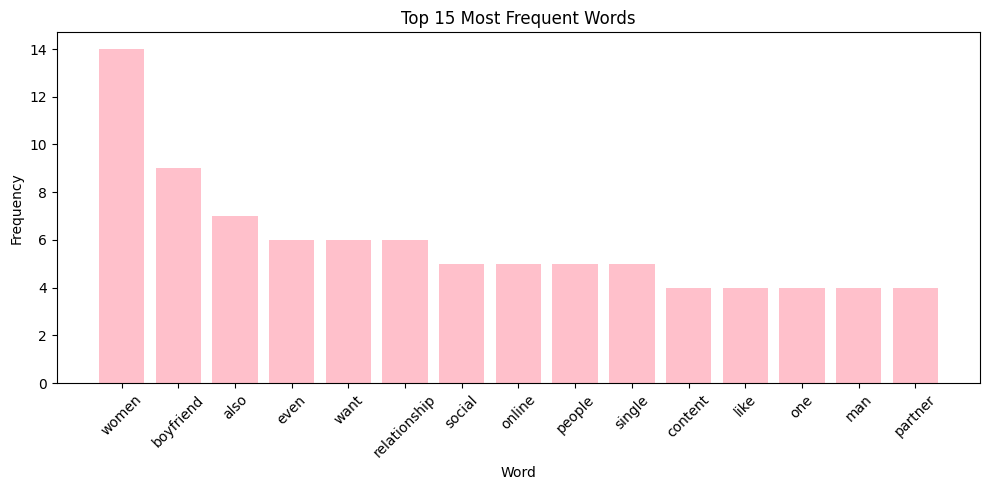

In [8]:
plt.figure(figsize=(10, 5))

plt.bar(
    top_words["Word"],
    top_words["Frequency"],
    color='pink'
)

plt.xticks(rotation=45)
plt.title("Top 15 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

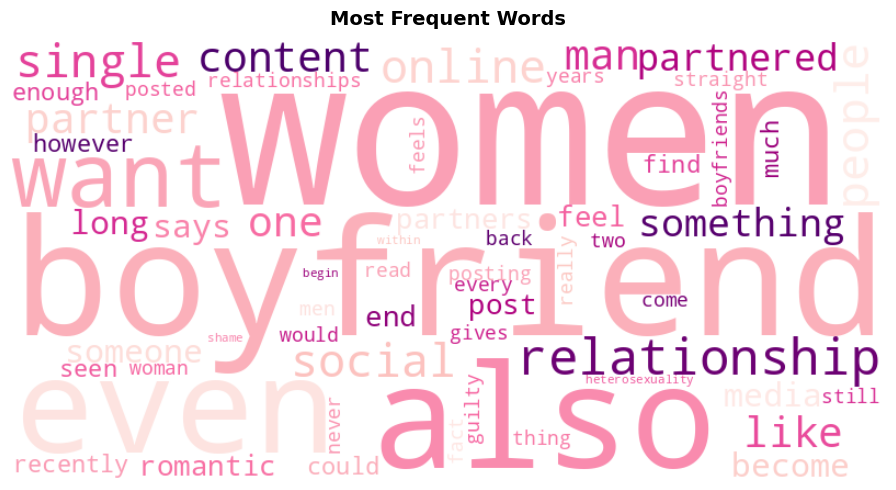

In [9]:
from wordcloud import WordCloud

wc = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='RdPu',
    max_words=60,
    prefer_horizontal=0.8
).generate_from_frequencies(freq_dist)

fig, ax = plt.subplots(figsize=(11, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Frequent Words', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 7. Lexical Diversity

Lexical diversity measures how varied the vocabulary of a text is. A common way to calculate it is the **type-token ratio (TTR)**: the number of unique word forms (types) divided by the total number of words (tokens). A higher TTR indicates a greater variety of vocabulary.

The cell below calculates the TTR for the cleaned corpus.


In [10]:
lexical_diversity = len(set(clean_tokens)) / len(clean_tokens)

print(f'Total words: {len(clean_tokens)}')
print(f'Unique words: {len(set(clean_tokens))}')
print("Lexical Diversity:", lexical_diversity)

Total words: 483
Unique words: 349
Lexical Diversity: 0.722567287784679


## 8. Part-of-Speech Tagging

Part-of-speech (POS) tagging assigns a grammatical label to each word in the text using the Penn Treebank tagset. This makes it possible to identify which grammatical categories are most prominent in the article.

The key tags used in this analysis are:

| Tag | Meaning | Example |
|-----|---------|--------|
| `NN` | Singular noun | *woman*, *relationship* |
| `NNS` | Plural noun | *women*, *men* |
| `JJ` | Adjective | *embarrassing*, *empowering* |
| `VBG` | Gerund / present participle | *having*, *celebrating* |
| `RB` | Adverb | *now*, *really* |
| `NNP` | Proper noun | *Vogue*, *Joseph* |

The first cell below tags the clean tokens and previews the first 20 results. The second cell counts the frequency of each POS category, and the third produces a bar chart.


In [11]:
tagged_words = pos_tag(clean_tokens)

tagged_words[:20]

[('someone', 'NN'),
 ('much', 'JJ'),
 ('says', 'VBZ'),
 ('social', 'JJ'),
 ('media', 'NNS'),
 ('muted', 'VBD'),
 ('nothing', 'NN'),
 ('hate', 'NN'),
 ('following', 'VBG'),
 ('someone', 'NN'),
 ('fun', 'NN'),
 ('content', 'NN'),
 ('become', 'VBN'),
 ('boyfriend', 'JJ'),
 ('suddenly', 'RB'),
 ('probably', 'RB'),
 ('long', 'RB'),
 ('felt', 'VBD'),
 ('like', 'IN'),
 ('living', 'VBG')]

In [12]:
pos_counts = {}

for word, tag in tagged_words:
    pos_counts[tag] = pos_counts.get(tag, 0) + 1

pos_df = pd.DataFrame(
    pos_counts.items(),
    columns=["POS", "Count"]
)

pos_df = pos_df.sort_values(
    by="Count",
    ascending=False
).reset_index(drop=True)

pos_df.head(10)

,POS,Count
0,NN,125
1,JJ,77
2,NNS,62
3,RB,62
4,VBG,35
5,VBP,33
6,VBD,21
7,VBN,20
8,VBZ,15
9,IN,11


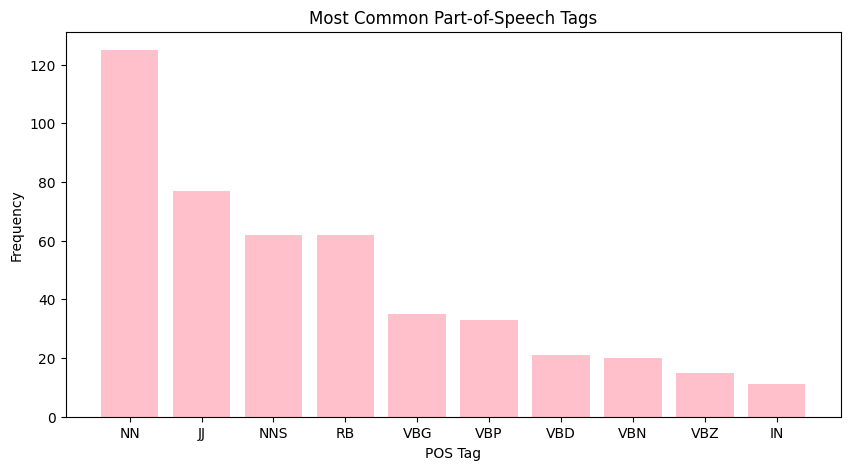

In [13]:
top_pos = pos_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_pos["POS"],
    top_pos["Count"],
    color='pink'
)

plt.title("Most Common Part-of-Speech Tags")
plt.xlabel("POS Tag")
plt.ylabel("Frequency")

plt.show()

Since nouns are the most frequent category, the cells below take a closer look at which specific nouns appear most often in the article. The first cell extracts all noun tokens and counts their frequency; the second displays the top 15 as a bar chart.

In [15]:
nouns = [
    word.lower()
    for word, tag in tagged_words
    if tag.startswith("NN")
]

noun_freq = Counter(nouns)

top_nouns = noun_freq.most_common(15)

pd.DataFrame(
    top_nouns,
    columns=["Noun", "Frequency"]
)

,Noun,Frequency
0,women,14
1,relationship,6
2,people,5
3,man,4
4,partner,4
5,something,4
6,someone,3
7,media,3
8,content,3
9,partners,3


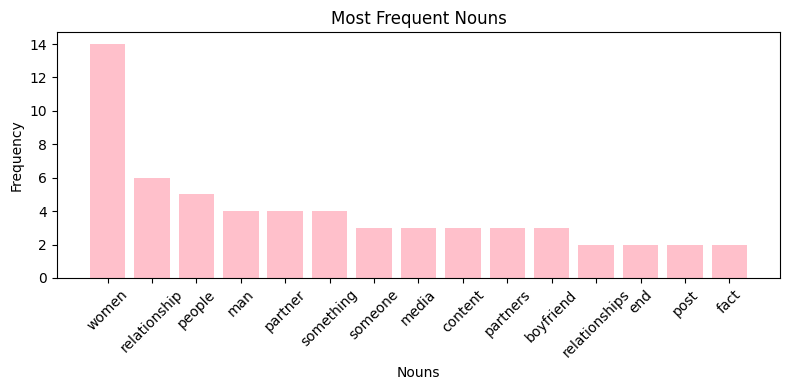

In [16]:
words = [word for word, count in top_nouns]
counts = [count for word, count in top_nouns]

plt.figure(figsize=(8, 4))
color ='pink'
plt.bar(words, counts, color=color)

plt.title("Most Frequent Nouns")
plt.xlabel("Nouns")
plt.ylabel("Frequency")


plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 9. Named Entity Recognition (NER)

Named Entity Recognition identifies references to real-world entities in the text: people, organisations and places. Examining which entities are mentioned, and how often, can reveal whose voices are cited and how the debate is framed in cultural terms.

The first cell below extracts all named entities using NLTK's `ne_chunk` function and displays the 15 most frequent ones as a table. The second cell visualises the top 10 as a pie chart.


In [17]:
tree = nltk.ne_chunk(nltk.pos_tag(tokens), binary=False)

entities = []

for chunk in tree:
    if hasattr(chunk, 'label'):
        entity = ' '.join(c[0] for c in chunk)
        entities.append((entity, chunk.label()))

entity_counts = Counter(entity for entity, label in entities)

pd.DataFrame(
    entity_counts.most_common(15),
    columns=['Entity', 'Frequency']
)

,Entity,Frequency
0,Substackers,1
1,Boyfriend Land,1
2,Zoé Samudzi,1
3,Instagram,1
4,Nikki,1
5,Delusional Diaries,1
6,Halley,1
7,Jaz,1
8,Republican,1
9,Funnily,1


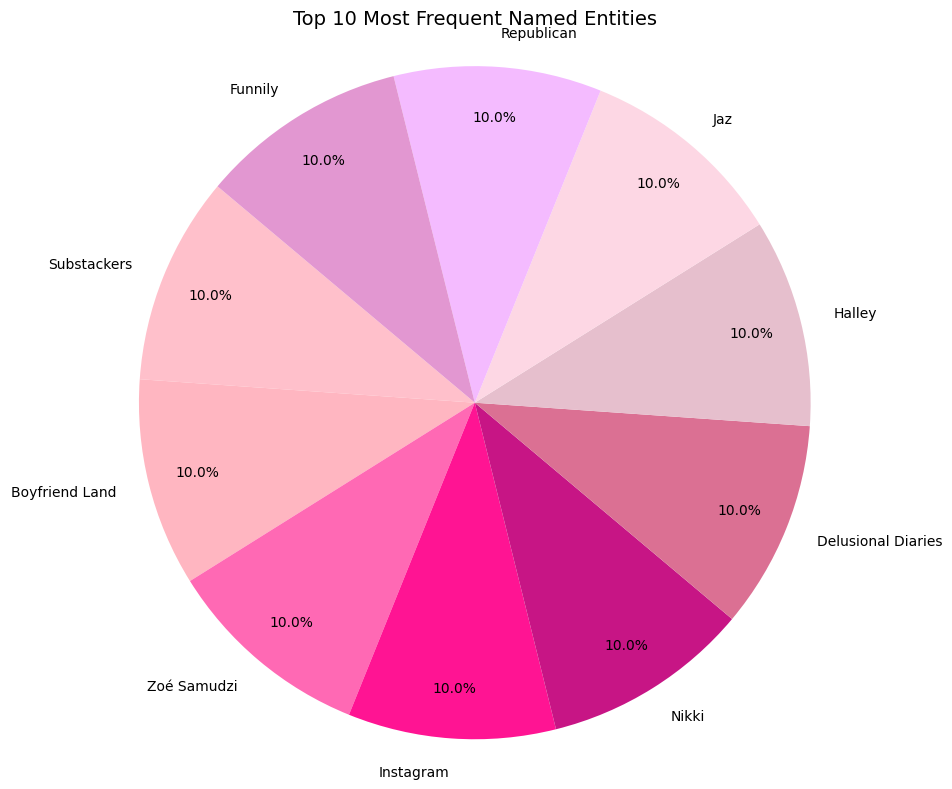

In [18]:
labels = [entity for entity, _ in entity_counts.most_common(10)]
sizes = [count for _, count in entity_counts.most_common(10)]

pink_shades = ['#FFC0CB', '#FFB6C1', '#FF69B4', '#FF1493', '#C71585', '#DB7093', '#E6BFCD', '#FDD7E4', '#F4BBFF', '#E297D1']

plt.figure(figsize=(10, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, pctdistance=0.85, textprops={'fontsize': 10}, colors=pink_shades)
plt.title('Top 10 Most Frequent Named Entities', fontsize=14)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

## 10. Results

This section summarises the numerical outputs produced by each step of the analysis.

**Corpus size**

The scraped article produced **1,207 tokens** in total, of which **497 were unique**. After removing stop words and non-alphabetic characters, the cleaned corpus contained **483 content words**, of which **349 were unique**.

**Most frequent words**

The 15 most frequent content words, in descending order, were: *women* (14), *boyfriend* (9), *also* (7), *even* (6), *want* (6), *relationship* (6), *social* (5), *online* (5), *people* (5), *single* (5), *content* (4), *like* (4), *one* (4), *man* (4) and *partner* (4). The dominance of *women*, *boyfriend* and *relationship* confirms that these three concepts form the thematic core of the text.

**Lexical diversity**

The type-token ratio (TTR) was approximately **0.72**, indicating a moderately high level of lexical variety. This is consistent with the genre of opinion journalism, which tends to return to a small set of key terms while drawing on varied supporting vocabulary around them.

**Part-of-speech distribution**

The ten most frequent POS tags were, in order: `NN` (singular nouns, 125), `JJ` (adjectives, 77), `NNS` (plural nouns, 62), `RB` (adverbs, 62), `VBG` (gerunds, 35), `VBP` (present tense verbs, 33), `VBD` (past tense verbs, 21), `VBN` (past participle verbs, 20), `VBZ` (third-person singular present verbs, 15) and `IN` (prepositions, 11). Singular nouns were by far the most frequent category, followed by adjectives and plural nouns.

**Named entities**

The named entity recognition step identified 15 entities, each appearing once. The low frequency of each entity reflects the article's relatively personal, essayistic style, which relies more on the author's own voice than on direct citation of external figures.

## 11. Conclusion

This notebook set out to examine the linguistic features of Chanté Joseph's British Vogue article on feminism and relationships. Using a small set of NLP tools, I identified patterns in vocabulary, grammatical structure and named entity use.

The frequency analysis showed that the text is organised around three central concepts: women, boyfriend and relationship. The TTR of 0.72 indicates a moderately high level of lexical variety, which is characteristic of opinion journalism that addresses a broad audience while repeatedly returning to a core set of thematic terms.

The POS results showed a clear predominance of singular nouns (125 occurrences), followed by adjectives (77) and plural nouns and adverbs (62 each). A closer look at the noun distribution revealed that the most frequent nouns were women, relationship, people, man and partner. This confirms that the article centres on romantic relationships and the social experiences of women within them. The presence of less specific nouns such as people, something and someone suggests that Joseph combines personal observations with broader social commentary, moving between individual anecdote and generalised claims about contemporary heterosexual culture.

The NER results were notably sparse: NLTK identified 15 entities, each appearing only once. This reflects the article's essayistic, first-person style, in which the author draws predominantly on her own perspective rather than on direct citations or references to multiple external sources. The entities that were identified, including writers such as Zoé Samudzi and Stephanie Yeboah and the platform Instagram, suggest that the debate is situated within a specific online feminist discourse community.

There are several limitations to this project. The corpus consists of a single article, which means the findings cannot be generalised to feminist discourse as a whole. In addition, NLTK's NER and POS tools are not always accurate on informal or online text and some entity classifications may be incorrect.

Despite these limitations, the project demonstrates that even basic NLP methods can surface patterns in media language that reward closer attention. A more extensive analysis might compare multiple articles on the same debate, apply sentiment analysis or use more advanced tools such as spaCy to improve the accuracy of entity classification.